In [2]:
import os
from pathlib import Path
from collections import defaultdict, Counter
import random
import csv

from PIL import Image


# 1. Configuration, edit these paths for your machine
RAW_ROOT = Path("D:\mycardial\rawdata for ECG")  # folder that contains the ECG Images... directory
OUT_ROOT = Path("data_iid")                # where we will write the balanced, preprocessed data

TARGET_SIZE = (224, 224)                   # for ResNet
RANDOM_SEED = 42


# 2. Discover all image files and infer labels from filenames
def infer_label_from_name(filename: str) -> str:
    """
    Extract alphabetic prefix from something like 'MI(123).jpg' or 'Normal(10).jpg'
    """
    name = Path(filename).stem
    prefix_chars = [ch for ch in name if ch.isalpha()]
    if not prefix_chars:
        raise ValueError(f"Could not infer label from {filename}")
    return "".join(prefix_chars)


def collect_images(raw_root: Path):
    """
    Recursively find all images and group them by label
    """
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    label_to_paths = defaultdict(list)

    for path in raw_root.rglob("*"):
        if not path.is_file():
            continue
        if path.suffix.lower() not in exts:
            continue

        label = infer_label_from_name(path.name)
        label_to_paths[label].append(path)

    return label_to_paths


label_to_paths = collect_images(RAW_ROOT)

print("Found classes and counts:")
for label, paths in label_to_paths.items():
    print(f"  {label}: {len(paths)} images")

# Optional, to check modes and sizes of a few images
from PIL import Image

modes = Counter()
sizes = Counter()
checked = 0

for paths in label_to_paths.values():
    for path in paths[:10]:
        img = Image.open(path)
        img.load()
        modes[img.mode] += 1
        sizes[img.size] += 1
        checked += 1

print("\nSample image modes:", modes)
print("Sample image sizes:", sizes)


# 3. Balance classes by undersampling to the smallest class size
random.seed(RANDOM_SEED)

class_counts = {label: len(paths) for label, paths in label_to_paths.items()}
min_count = min(class_counts.values())

print("\nClass counts:", class_counts)
print("Using min_count =", min_count, "for all classes to get a balanced pool.")

balanced_records = []  # each item is (label, path)

for label, paths in label_to_paths.items():
    if len(paths) < min_count:
        raise ValueError(f"Class {label} has fewer samples than min_count, something is odd")
    selected = random.sample(paths, min_count)
    for p in selected:
        balanced_records.append((label, p))

print("Total balanced samples:", len(balanced_records))


# 4. Build stratified train, val, test splits for IID case
def stratified_split(records, train_ratio=0.7, val_ratio=0.15):
    """
    records: list of (label, path)
    returns: list of (label, path, split) where split in {'train','val','test'}
    """
    by_label = defaultdict(list)
    for label, path in records:
        by_label[label].append(path)

    all_splits = []

    for label, paths in by_label.items():
        paths = list(paths)
        random.shuffle(paths)
        n = len(paths)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)
        n_test = n - n_train - n_val

        train_paths = paths[:n_train]
        val_paths = paths[n_train:n_train + n_val]
        test_paths = paths[n_train + n_val:]

        print(
            f"Label {label}: total {n}, train {len(train_paths)}, "
            f"val {len(val_paths)}, test {len(test_paths)}"
        )

        for p in train_paths:
            all_splits.append((label, p, "train"))
        for p in val_paths:
            all_splits.append((label, p, "val"))
        for p in test_paths:
            all_splits.append((label, p, "test"))

    return all_splits


split_records = stratified_split(balanced_records)


# 5. Create output directories
for split in ["train", "val", "test"]:
    for label in label_to_paths.keys():
        out_dir = OUT_ROOT / split / label
        out_dir.mkdir(parents=True, exist_ok=True)
import os
from pathlib import Path
from collections import defaultdict, Counter
import random
import csv

from PIL import Image


# 1. Configuration, edit these paths for your machine
RAW_ROOT = Path("D:\mycardial\rawdata for ECG")  # folder that contains the ECG Images... directory
OUT_ROOT = Path("data_iid")                # where we will write the balanced, preprocessed data

TARGET_SIZE = (224, 224)                   # for ResNet
RANDOM_SEED = 42


# 2. Discover all image files and infer labels from filenames
def infer_label_from_name(filename: str) -> str:
    """
    Extract alphabetic prefix from something like 'MI(123).jpg' or 'Normal(10).jpg'
    """
    name = Path(filename).stem
    prefix_chars = [ch for ch in name if ch.isalpha()]
    if not prefix_chars:
        raise ValueError(f"Could not infer label from {filename}")
    return "".join(prefix_chars)


def collect_images(raw_root: Path):
    """
    Recursively find all images and group them by label
    """
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    label_to_paths = defaultdict(list)

    for path in raw_root.rglob("*"):
        if not path.is_file():
            continue
        if path.suffix.lower() not in exts:
            continue

        label = infer_label_from_name(path.name)
        label_to_paths[label].append(path)

    return label_to_paths


label_to_paths = collect_images(RAW_ROOT)

print("Found classes and counts:")
for label, paths in label_to_paths.items():
    print(f"  {label}: {len(paths)} images")

# Optional, to check modes and sizes of a few images
from PIL import Image

modes = Counter()
sizes = Counter()
checked = 0

for paths in label_to_paths.values():
    for path in paths[:10]:
        img = Image.open(path)
        img.load()
        modes[img.mode] += 1
        sizes[img.size] += 1
        checked += 1

print("\nSample image modes:", modes)
print("Sample image sizes:", sizes)


# 3. Balance classes by undersampling to the smallest class size
random.seed(RANDOM_SEED)

class_counts = {label: len(paths) for label, paths in label_to_paths.items()}
min_count = min(class_counts.values())

print("\nClass counts:", class_counts)
print("Using min_count =", min_count, "for all classes to get a balanced pool.")

balanced_records = []  # each item is (label, path)

for label, paths in label_to_paths.items():
    if len(paths) < min_count:
        raise ValueError(f"Class {label} has fewer samples than min_count, something is odd")
    selected = random.sample(paths, min_count)
    for p in selected:
        balanced_records.append((label, p))

print("Total balanced samples:", len(balanced_records))


# 4. Build stratified train, val, test splits for IID case
def stratified_split(records, train_ratio=0.7, val_ratio=0.15):
    """
    records: list of (label, path)
    returns: list of (label, path, split) where split in {'train','val','test'}
    """
    by_label = defaultdict(list)
    for label, path in records:
        by_label[label].append(path)

    all_splits = []

    for label, paths in by_label.items():
        paths = list(paths)
        random.shuffle(paths)
        n = len(paths)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)
        n_test = n - n_train - n_val

        train_paths = paths[:n_train]
        val_paths = paths[n_train:n_train + n_val]
        test_paths = paths[n_train + n_val:]

        print(
            f"Label {label}: total {n}, train {len(train_paths)}, "
            f"val {len(val_paths)}, test {len(test_paths)}"
        )

        for p in train_paths:
            all_splits.append((label, p, "train"))
        for p in val_paths:
            all_splits.append((label, p, "val"))
        for p in test_paths:
            all_splits.append((label, p, "test"))

    return all_splits


split_records = stratified_split(balanced_records)


# 5. Create output directories
for split in ["train", "val", "test"]:
    for label in label_to_paths.keys():
        out_dir = OUT_ROOT / split / label
        out_dir.mkdir(parents=True, exist_ok=True)


# 6. Process images: grayscale and resize, then save to the split folders
metadata_rows = []

for label, src_path, split in split_records:
    img = Image.open(src_path)
    img = img.convert("L")                # grayscale
    img = img.resize(TARGET_SIZE)         # 224 x 224

    dest_dir = OUT_ROOT / split / label
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Keep the original filename for traceability
    dest_path = dest_dir / src_path.name
    img.save(dest_path)

    rel_path = dest_path.relative_to(OUT_ROOT)
    metadata_rows.append([str(rel_path), label, split])

print("\nPreprocessing complete.")
print("Output root:", OUT_ROOT)


# 7. Write metadata CSV describing the IID balanced dataset
meta_path = OUT_ROOT / "metadata_iid.csv"
with open(meta_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["relative_path", "label", "split"])
    writer.writerows(metadata_rows)

print("Wrote metadata to:", meta_path)


# 6. Process images: grayscale and resize, then save to the split folders
metadata_rows = []

for label, src_path, split in split_records:
    img = Image.open(src_path)
    img = img.convert("L")                # grayscale
    img = img.resize(TARGET_SIZE)         # 224 x 224

    dest_dir = OUT_ROOT / split / label
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Keep the original filename for traceability
    dest_path = dest_dir / src_path.name
    img.save(dest_path)

    rel_path = dest_path.relative_to(OUT_ROOT)
    metadata_rows.append([str(rel_path), label, split])

print("\nPreprocessing complete.")
print("Output root:", OUT_ROOT)


# 7. Write metadata CSV describing the IID balanced dataset
meta_path = OUT_ROOT / "metadata_iid.csv"
with open(meta_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["relative_path", "label", "split"])
    writer.writerows(metadata_rows)

print("Wrote metadata to:", meta_path)


Found classes and counts:

Sample image modes: Counter()
Sample image sizes: Counter()


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\m'
C:\Users\DELL\AppData\Local\Temp\ipykernel_16140\2882555032.py:11: SyntaxWarning: invalid escape sequence '\m'
  RAW_ROOT = Path("D:\mycardial\rawdata for ECG")  # folder that contains the ECG Images... directory
C:\Users\DELL\AppData\Local\Temp\ipykernel_16140\2882555032.py:152: SyntaxWarning: invalid escape sequence '\m'
  RAW_ROOT = Path("D:\mycardial\rawdata for ECG")  # folder that contains the ECG Images... directory


ValueError: min() iterable argument is empty

In [1]:
import os
from pathlib import Path
from collections import defaultdict, Counter
import random
import csv
from PIL import Image

# 1. Configuration, EDIT THESE TWO
RAW_ROOT = Path(r"D:\mycardial\rawdata for ECG")
# This folder should directly contain:
#   ECG Images of Patient that have History of MI (172x12=2064)
#   ECG Images of Patient that have abnormal heartbeat (233x12=2796)
#   ECG Images of Myocardial Infarction Patients (240x12=2880)
#   Normal Person ECG Images (284x12=3408)

OUT_ROOT = Path("data_iid")  # processed balanced output

TARGET_SIZE = (224, 224)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# 2. Basic sanity checks
if not RAW_ROOT.exists():
    raise FileNotFoundError(f"RAW_ROOT does not exist: {RAW_ROOT}")

print("RAW_ROOT:", RAW_ROOT)
print("Immediate children of RAW_ROOT:")
for p in RAW_ROOT.iterdir():
    print(" ", p)

# 3. Collect images and infer labels from filenames
def infer_label_from_name(filename: str) -> str:
    """
    Extract alphabetic prefix from something like 'MI(123).jpg' or 'Normal(10).jpg'
    """
    stem = Path(filename).stem
    prefix_chars = [ch for ch in stem if ch.isalpha()]
    if not prefix_chars:
        raise ValueError(f"Could not infer label from filename: {filename}")
    return "".join(prefix_chars)


def collect_images(raw_root: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    label_to_paths = defaultdict(list)

    for path in raw_root.rglob("*"):
        if not path.is_file():
            continue
        if path.suffix.lower() not in exts:
            continue
        label = infer_label_from_name(path.name)
        label_to_paths[label].append(path)

    return label_to_paths


label_to_paths = collect_images(RAW_ROOT)

if not label_to_paths:
    raise RuntimeError(
        f"No images found under {RAW_ROOT}. "
        "Check that the path is correct and that it contains jpg or png files."
    )

print("\nFound classes and counts:")
for label, paths in label_to_paths.items():
    print(f"  {label}: {len(paths)} images")

# 4. Quick check of image modes and sizes
modes = Counter()
sizes = Counter()
sample_paths = []
for paths in label_to_paths.values():
    sample_paths.extend(paths)
sample_paths = sample_paths[:50]  # just a sample

for p in sample_paths:
    img = Image.open(p)
    img.load()
    modes[img.mode] += 1
    sizes[img.size] += 1

print("\nSample image modes:", dict(modes))
print("Top sample image sizes:")
for size, count in sizes.most_common(5):
    print(" ", size, "->", count, "images")

# 5. Balance classes by undersampling to smallest class size
class_counts = {label: len(paths) for label, paths in label_to_paths.items()}
if not class_counts:
    raise RuntimeError("No class counts found, did not collect images correctly.")

min_count = min(class_counts.values())

print("\nClass counts:", class_counts)
print("Using min_count =", min_count, "per class for balanced pool.")

balanced_records = []  # list of (label, path)

for label, paths in label_to_paths.items():
    if len(paths) < min_count:
        raise ValueError(f"Class {label} has fewer samples than min_count. Something is wrong.")
    selected = random.sample(paths, min_count)
    for p in selected:
        balanced_records.append((label, p))

print("Total balanced samples:", len(balanced_records))


# 6. Stratified train, val, test split (IID per class)
def stratified_split(records, train_ratio=0.7, val_ratio=0.15):
    by_label = defaultdict(list)
    for label, path in records:
        by_label[label].append(path)

    all_splits = []  # list of (label, path, split)

    for label, paths in by_label.items():
        paths = list(paths)
        random.shuffle(paths)
        n = len(paths)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)
        n_test = n - n_train - n_val

        train_paths = paths[:n_train]
        val_paths = paths[n_train:n_train + n_val]
        test_paths = paths[n_train + n_val:]

        print(
            f"Label {label}: total {n}, train {len(train_paths)}, "
            f"val {len(val_paths)}, test {len(test_paths)}"
        )

        for p in train_paths:
            all_splits.append((label, p, "train"))
        for p in val_paths:
            all_splits.append((label, p, "val"))
        for p in test_paths:
            all_splits.append((label, p, "test"))

    return all_splits


split_records = stratified_split(balanced_records)

# 7. Create output directories
for split in ["train", "val", "test"]:
    for label in label_to_paths.keys():
        out_dir = OUT_ROOT / split / label
        out_dir.mkdir(parents=True, exist_ok=True)

# 8. Process images: grayscale and resize, then save
metadata_rows = []

for label, src_path, split in split_records:
    img = Image.open(src_path)
    img = img.convert("L")          # grayscale
    img = img.resize(TARGET_SIZE)   # 224 x 224

    dest_dir = OUT_ROOT / split / label
    dest_dir.mkdir(parents=True, exist_ok=True)

    dest_path = dest_dir / src_path.name
    img.save(dest_path)

    rel_path = dest_path.relative_to(OUT_ROOT)
    metadata_rows.append([str(rel_path), label, split])

print("\nPreprocessing complete.")
print("Output root:", OUT_ROOT)

# 9. Write metadata CSV
meta_path = OUT_ROOT / "metadata_iid.csv"
with open(meta_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["relative_path", "label", "split"])
    writer.writerows(metadata_rows)

print("Wrote metadata to:", meta_path)


RAW_ROOT: D:\mycardial\rawdata for ECG
Immediate children of RAW_ROOT:
  D:\mycardial\rawdata for ECG\ECG Images of Myocardial Infarction Patients (240x12=2880)
  D:\mycardial\rawdata for ECG\ECG Images of Patient that have abnormal heartbeat (233x12=2796)
  D:\mycardial\rawdata for ECG\ECG Images of Patient that have History of MI (172x12=2064)
  D:\mycardial\rawdata for ECG\Normal Person ECG Images (284x12=3408)

Found classes and counts:
  MI: 239 images
  HB: 233 images
  PMI: 172 images
  Normal: 284 images

Sample image modes: {'RGB': 50}
Top sample image sizes:
  (2213, 1572) -> 50 images

Class counts: {'MI': 239, 'HB': 233, 'PMI': 172, 'Normal': 284}
Using min_count = 172 per class for balanced pool.
Total balanced samples: 688
Label MI: total 172, train 120, val 25, test 27
Label HB: total 172, train 120, val 25, test 27
Label PMI: total 172, train 120, val 25, test 27
Label Normal: total 172, train 120, val 25, test 27

Preprocessing complete.
Output root: data_iid
Wrote met

##Load metadata and show basic stats

In [2]:
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("data_iid")
meta_path = DATA_ROOT / "metadata_iid.csv"

meta = pd.read_csv(meta_path)
print(meta.head())

print("\nLabel counts overall:")
print(meta["label"].value_counts())

print("\nLabel counts by split:")
print(meta.groupby(["split", "label"]).size())


         relative_path label  split
0  train\MI\MI(12).jpg    MI  train
1  train\MI\MI(20).jpg    MI  train
2  train\MI\MI(32).jpg    MI  train
3  train\MI\MI(47).jpg    MI  train
4  train\MI\MI(49).jpg    MI  train

Label counts overall:
label
MI        172
HB        172
PMI       172
Normal    172
Name: count, dtype: int64

Label counts by split:
split  label 
test   HB         27
       MI         27
       Normal     27
       PMI        27
train  HB        120
       MI        120
       Normal    120
       PMI       120
val    HB         25
       MI         25
       Normal     25
       PMI        25
dtype: int64


#Visual sanity check, a few samples per class

Classes: ['HB', 'MI', 'Normal', 'PMI']


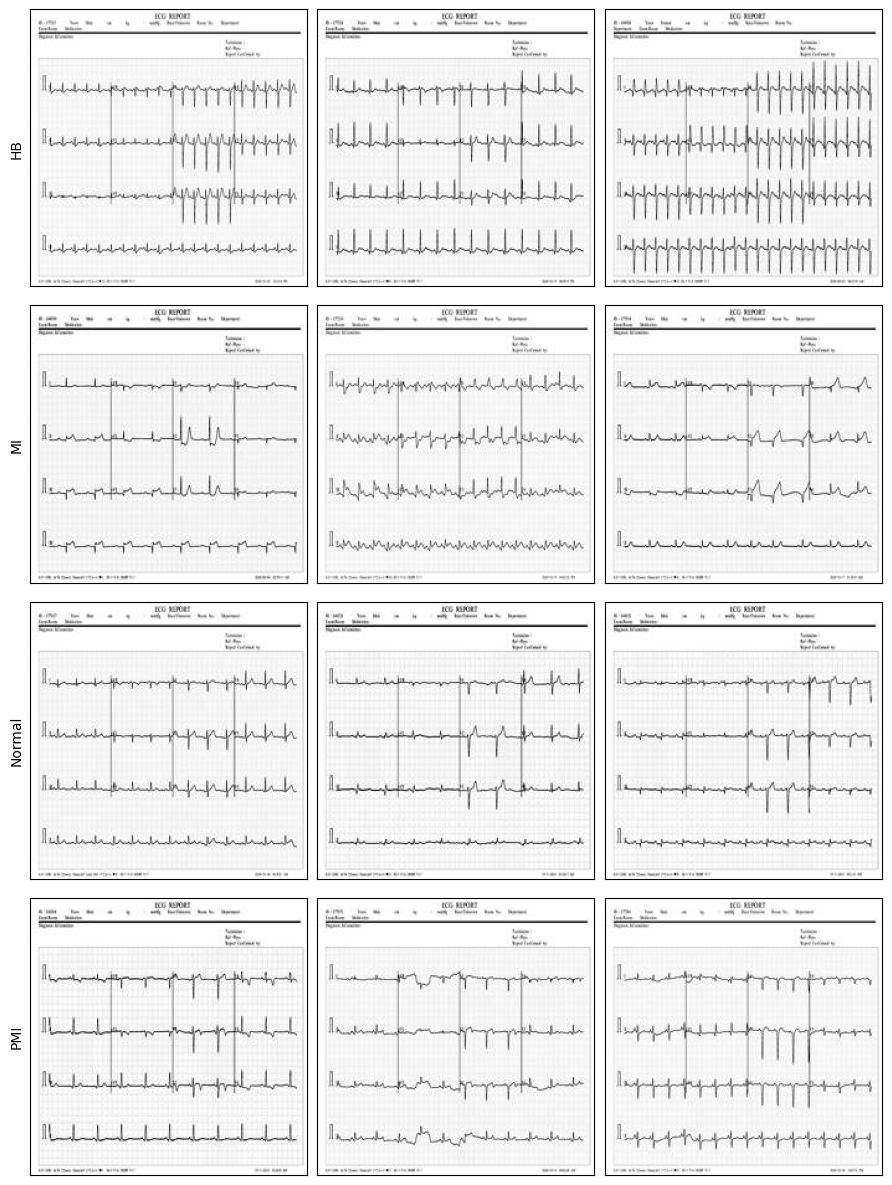

In [3]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# We will only visualize from the train split for now
train_meta = meta[meta["split"] == "train"].copy()
classes = sorted(train_meta["label"].unique())
print("Classes:", classes)

def show_samples_per_class(df, data_root, samples_per_class=3):
    n_classes = len(classes)
    fig, axes = plt.subplots(
        n_classes, samples_per_class,
        figsize=(3 * samples_per_class, 3 * n_classes)
    )
    
    if n_classes == 1:
        axes = np.expand_dims(axes, 0)
    
    for row_idx, label in enumerate(classes):
        df_label = df[df["label"] == label]
        # if class has fewer than requested, just use all
        chosen = df_label.sample(
            n=min(samples_per_class, len(df_label)),
            random_state=42
        )
        for col_idx, (_, row) in enumerate(chosen.iterrows()):
            rel_path = row["relative_path"]
            img_path = data_root / rel_path
            img = Image.open(img_path)
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap="gray")
            ax.set_xticks([])
            ax.set_yticks([])
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=10)
    
    plt.tight_layout()
    plt.show()

show_samples_per_class(train_meta, DATA_ROOT, samples_per_class=3)


##Mean image pattern for each condition

         relative_path label  split
0  train\MI\MI(12).jpg    MI  train
1  train\MI\MI(20).jpg    MI  train
2  train\MI\MI(32).jpg    MI  train
3  train\MI\MI(47).jpg    MI  train
4  train\MI\MI(49).jpg    MI  train

Label counts overall:
label
MI        172
HB        172
PMI       172
Normal    172
Name: count, dtype: int64

Label counts by split:
split  label 
test   HB         27
       MI         27
       Normal     27
       PMI        27
train  HB        120
       MI        120
       Normal    120
       PMI       120
val    HB         25
       MI         25
       Normal     25
       PMI        25
dtype: int64

Classes: ['HB', 'MI', 'Normal', 'PMI']


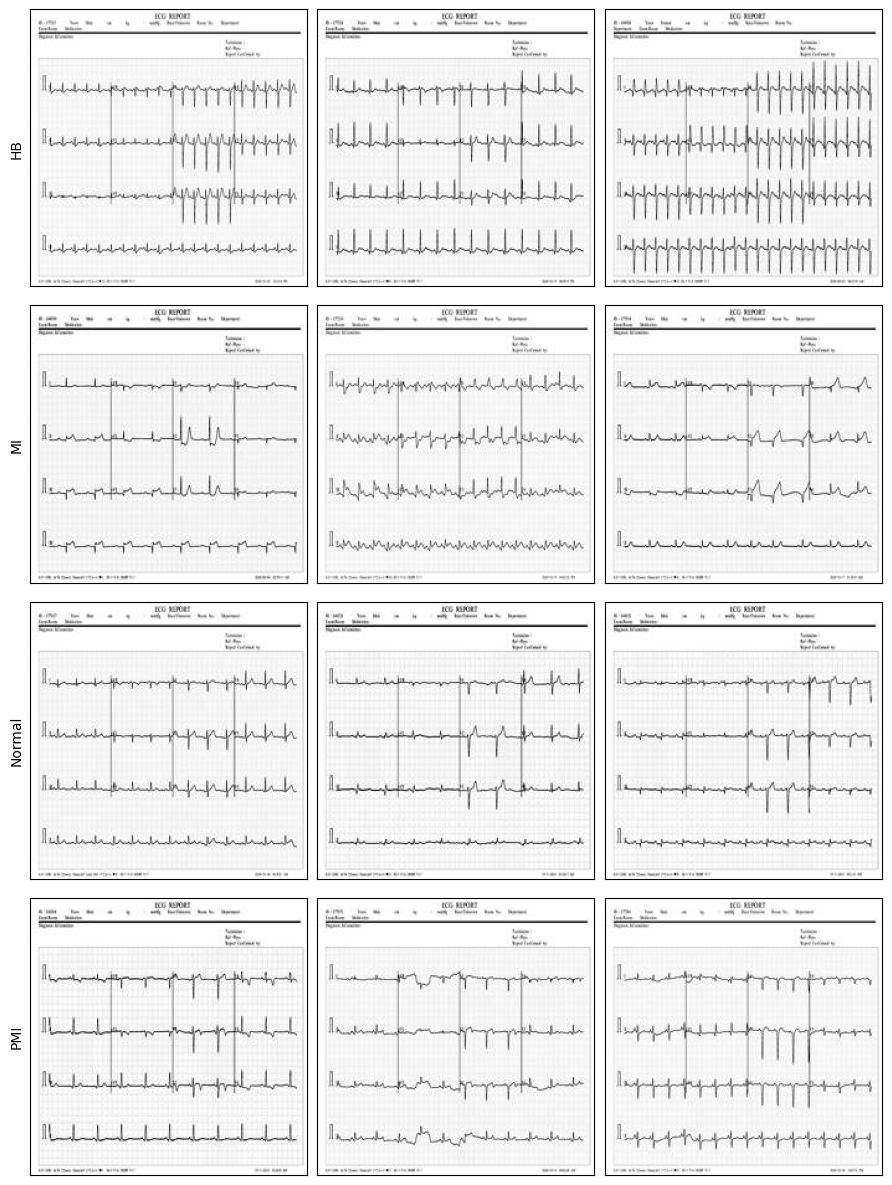

Mean for PMI: 100%|██████████| 120/120 [00:00<00:00, 1814.31it/s]


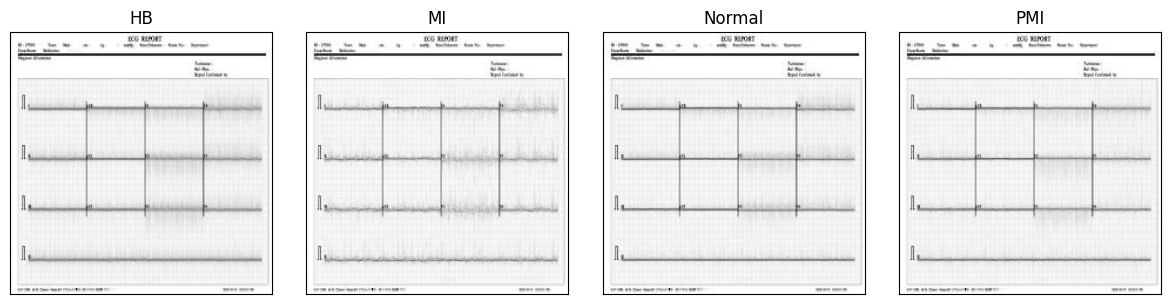

Global mean: 100%|██████████| 480/480 [00:00<00:00, 1555.64it/s]


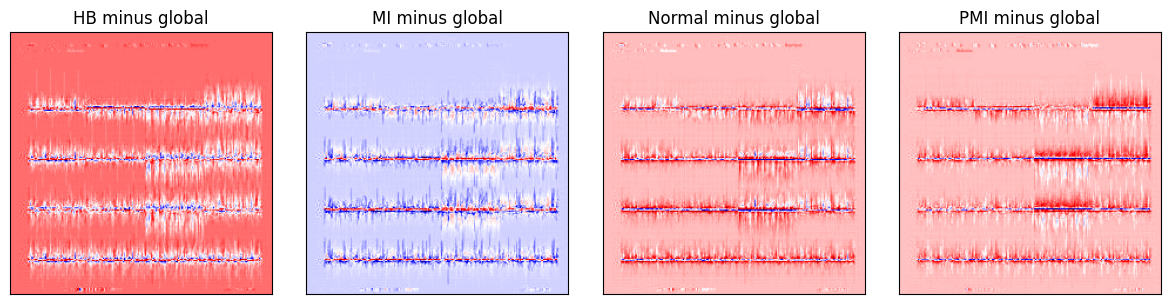

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import random

# 0. Paths
DATA_ROOT = Path("data_iid")  # folder created in step 0 and 1
meta_path = DATA_ROOT / "metadata_iid.csv"

# 1. Load metadata and inspect distribution
meta = pd.read_csv(meta_path)
print(meta.head())

print("\nLabel counts overall:")
print(meta["label"].value_counts())

print("\nLabel counts by split:")
print(meta.groupby(["split", "label"]).size())

# Define classes (sorted for consistency)
train_meta = meta[meta["split"] == "train"].copy()
classes = sorted(train_meta["label"].unique())
print("\nClasses:", classes)

# 2. Visual sanity check: a few samples per class from train split
def show_samples_per_class(df, data_root, samples_per_class=3, seed=42):
    random.seed(seed)
    n_classes = len(classes)
    fig, axes = plt.subplots(
        n_classes, samples_per_class,
        figsize=(3 * samples_per_class, 3 * n_classes)
    )

    if n_classes == 1:
        axes = np.expand_dims(axes, 0)

    for row_idx, label in enumerate(classes):
        df_label = df[df["label"] == label]
        if len(df_label) == 0:
            continue
        chosen = df_label.sample(
            n=min(samples_per_class, len(df_label)),
            random_state=seed
        )
        for col_idx, (_, row) in enumerate(chosen.iterrows()):
            rel_path = row["relative_path"]
            img_path = data_root / rel_path
            img = Image.open(img_path)
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap="gray")
            ax.set_xticks([])
            ax.set_yticks([])
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=10)

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_meta, DATA_ROOT, samples_per_class=3)

# 3. Compute mean image for each class on the train split
def compute_mean_image_for_label(df, label, data_root):
    df_label = df[df["label"] == label]
    n = len(df_label)
    if n == 0:
        raise ValueError(f"No samples for label {label}")

    accumulator = None

    for _, row in tqdm(df_label.iterrows(), total=n, desc=f"Mean for {label}"):
        rel_path = row["relative_path"]
        img_path = data_root / rel_path
        img = Image.open(img_path).convert("L")
        arr = np.array(img, dtype=np.float32)
        if accumulator is None:
            accumulator = np.zeros_like(arr, dtype=np.float32)
        accumulator += arr

    mean_img = accumulator / n
    return mean_img

mean_images = {}
for label in classes:
    mean_images[label] = compute_mean_image_for_label(train_meta, label, DATA_ROOT)

# 4. Plot mean images side by side
n_classes = len(classes)
fig, axes = plt.subplots(1, n_classes, figsize=(3 * n_classes, 3))

for idx, label in enumerate(classes):
    ax = axes[idx]
    ax.imshow(mean_images[label], cmap="gray")
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# 5. Optional: global mean and class difference maps
all_train_imgs = []
for _, row in tqdm(train_meta.iterrows(), total=len(train_meta), desc="Global mean"):
    rel_path = row["relative_path"]
    img_path = DATA_ROOT / rel_path
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.float32)
    all_train_imgs.append(arr)

all_train_stack = np.stack(all_train_imgs, axis=0)
global_mean = all_train_stack.mean(axis=0)

fig, axes = plt.subplots(1, n_classes, figsize=(3 * n_classes, 3))
for idx, label in enumerate(classes):
    diff = mean_images[label] - global_mean
    ax = axes[idx]
    im = ax.imshow(diff, cmap="seismic")
    ax.set_title(f"{label} minus global")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


code, Dataset and DataLoaders for IID ECG data

In [3]:
import os
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Paths and basic config
DATA_ROOT = Path("data_iid")  # same root used in step 0 and 1

train_dir = DATA_ROOT / "train"
val_dir   = DATA_ROOT / "val"
test_dir  = DATA_ROOT / "test"

BATCH_SIZE = 32
NUM_WORKERS = 2  # adjust if you have more CPU cores


# 2. Define transforms

# Option 1: simple normalization around 0.5 (works fine as a start)
# If you want, we can later compute exact mean and std from train set.
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # just to be safe
    transforms.RandomHorizontalFlip(p=0.5),       # mild augmentation
    transforms.RandomRotation(degrees=5),         # small rotation, ECG pages can be slightly tilted
    transforms.ToTensor(),                        # converts to [0, 1], shape [1, H, W]
    transforms.Normalize(mean=[0.5], std=[0.5]),  # maps to roughly [-1, 1]
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


# 3. Create datasets using ImageFolder
# ImageFolder expects: root/class_name/image_file
# That exactly matches data_iid structure

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_test_transform)

print("Number of samples:")
print("  Train:", len(train_dataset))
print("  Val:  ", len(val_dataset))
print("  Test: ", len(test_dataset))

print("\nClass to index mapping (ImageFolder):")
print(train_dataset.class_to_idx)


# 4. Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,      # shuffle for training
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# 5. Quick sanity check: fetch one batch and inspect shapes

batch = next(iter(train_loader))
images, labels = batch

print("\nBatch shapes:")
print("  images:", images.shape)   # expected: [BATCH_SIZE, 1, 224, 224]
print("  labels:", labels.shape)   # expected: [BATCH_SIZE]

print("\nUnique labels in this batch:", labels.unique())

# Map numeric labels back to class names for human sanity
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
decoded_labels = [idx_to_class[int(i)] for i in labels]
print("Decoded labels for first few samples:", decoded_labels[:10])


Number of samples:
  Train: 480
  Val:   100
  Test:  108

Class to index mapping (ImageFolder):
{'HB': 0, 'MI': 1, 'Normal': 2, 'PMI': 3}


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Batch shapes:
  images: torch.Size([32, 1, 224, 224])
  labels: torch.Size([32])

Unique labels in this batch: tensor([0, 1, 2, 3])
Decoded labels for first few samples: ['HB', 'HB', 'MI', 'Normal', 'MI', 'MI', 'Normal', 'Normal', 'MI', 'Normal']


ResNet model and training loop

In [5]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Number of classes from the dataset
num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)
print("num_classes:", num_classes)

# 3. Build ResNet18 adapted for 1 channel input and 4 class output
try:
    # newer torchvision
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except AttributeError:
    # older torchvision
    base_model = models.resnet18(pretrained=True)

# adapt first conv to 1 channel using averaged RGB weights
old_conv = base_model.conv1
base_model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)
with torch.no_grad():
    base_model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

# adapt final fully connected layer
in_features = base_model.fc.in_features
base_model.fc = nn.Linear(in_features, num_classes)

model = base_model.to(device)
print(model)

# 4. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

# Older PyTorch version, so we do not pass verbose
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

# 5. Training and evaluation helpers
def run_one_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is provided, run training.
    If optimizer is None, run evaluation.
    Returns loss and accuracy.
    """
    if optimizer is None:
        model.eval()
        torch.set_grad_enabled(False)
    else:
        model.train()
        torch.set_grad_enabled(True)

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# 6. Main training loop
num_epochs = 15
best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_one_epoch(
        model, train_loader, criterion, optimizer=optimizer, device=device
    )
    val_loss, val_acc = run_one_epoch(
        model, val_loader, criterion, optimizer=None, device=device
    )

    # step scheduler using validation accuracy
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
        f"lr={current_lr:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()

print("Best validation accuracy:", best_val_acc)

# 7. Load best and evaluate on test set
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_acc = run_one_epoch(
    model, test_loader, criterion, optimizer=None, device=device
)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 8. Save model
save_path = "resnet18_ecg_iid_best.pth"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
    },
    save_path,
)
print("Saved best model to", save_path)


Using device: cpu
Classes: ['HB', 'MI', 'Normal', 'PMI']
num_classes: 4
ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

#detailed evaluation on test set

##Collect predictions and true labels

In [6]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Eval device:", device)

# If you still have `model` from training and it is already loaded with best_state_dict, skip reload.
# If you restarted your notebook, reload from checkpoint:

from torchvision import models
import torch.nn as nn

checkpoint_path = "resnet18_ecg_iid_best.pth"
ckpt = torch.load(checkpoint_path, map_location=device)
class_to_idx = ckpt["class_to_idx"]

# Rebuild the same model architecture
num_classes = len(class_to_idx)

try:
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except AttributeError:
    base_model = models.resnet18(pretrained=True)

old_conv = base_model.conv1
base_model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)
with torch.no_grad():
    base_model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

in_features = base_model.fc.in_features
base_model.fc = nn.Linear(in_features, num_classes)

model = base_model.to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Map indices back to class names
idx_to_class = {v: k for k, v in class_to_idx.items()}
print("Class mapping:", idx_to_class)

# Collect predictions on test set
all_preds = []
all_true = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.append(predicted.cpu().numpy())
        all_true.append(targets.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_true = np.concatenate(all_true, axis=0)

print("Collected predictions:", all_preds.shape, all_true.shape)


Eval device: cpu
Class mapping: {0: 'HB', 1: 'MI', 2: 'Normal', 3: 'PMI'}
Collected predictions: (108,) (108,)


#Confusion matrix and classification report

Confusion matrix (rows true, cols predicted):
[[25  0  0  2]
 [ 0 27  0  0]
 [ 0  0 27  0]
 [ 0  0  0 27]]

Classification report:
              precision    recall  f1-score   support

          HB       1.00      0.93      0.96        27
          MI       1.00      1.00      1.00        27
      Normal       1.00      1.00      1.00        27
         PMI       0.93      1.00      0.96        27

    accuracy                           0.98       108
   macro avg       0.98      0.98      0.98       108
weighted avg       0.98      0.98      0.98       108



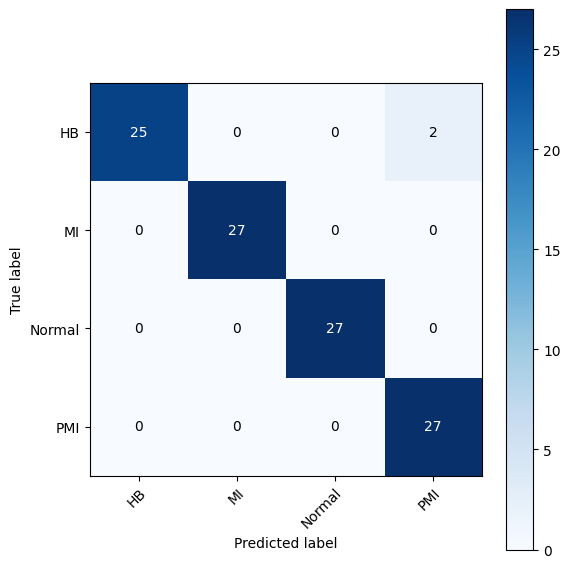

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

labels_sorted = sorted(idx_to_class.keys())
label_names = [idx_to_class[i] for i in labels_sorted]

cm = confusion_matrix(all_true, all_preds, labels=labels_sorted)
print("Confusion matrix (rows true, cols predicted):")
print(cm)

print("\nClassification report:")
print(classification_report(all_true, all_preds, target_names=label_names))

# Nice confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(label_names)),
    yticks=np.arange(len(label_names)),
    xticklabels=label_names,
    yticklabels=label_names,
    ylabel="True label",
    xlabel="Predicted label",
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
plt.show()


##Define transforms and prediction function

In [9]:
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F

# Transform must match val_test_transform from Step 3
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

def load_model_from_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    class_to_idx = ckpt["class_to_idx"]

    num_classes = len(class_to_idx)

    try:
        base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except AttributeError:
        base_model = models.resnet18(pretrained=True)

    old_conv = base_model.conv1
    base_model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        base_model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

    in_features = base_model.fc.in_features
    base_model.fc = nn.Linear(in_features, num_classes)

    model = base_model.to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    idx_to_class = {v: k for k, v in class_to_idx.items()}
    return model, class_to_idx, idx_to_class

# Only load once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, class_to_idx, idx_to_class = load_model_from_checkpoint(
    "resnet18_ecg_iid_best.pth",
    device
)

def predict_ecg_image(image_path, model, idx_to_class, device):
    img = Image.open(image_path)
    img = inference_transform(img)
    img = img.unsqueeze(0).to(device)  # shape [1, 1, 224, 224]

    with torch.no_grad():
        outputs = model(img)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]

    # Build dict of class probabilities
    prob_dict = {idx_to_class[i]: float(probs[i]) for i in range(len(probs))}

    return pred_label, prob_dict

# Quick test on one image from your test set
from pathlib import Path

some_test_img, some_label_idx = test_dataset[0]
some_test_path = test_dataset.samples[0][0]  # original path

print("Test image path:", some_test_path)

pred_label, prob_dict = predict_ecg_image(
    some_test_path,
    model,
    idx_to_class,
    device
)
print("Predicted:", pred_label)
print("Probabilities:", prob_dict)


Test image path: data_iid\test\HB\HB(10).jpg
Predicted: PMI
Probabilities: {'HB': 0.060817841440439224, 'MI': 0.000937703880481422, 'Normal': 0.005187585484236479, 'PMI': 0.9330568909645081}


simple user facing UI (Gradio)

In [10]:
pip install gradio


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/63.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/63.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/63.5 MB 1.5 MB/s eta 0:00:41
   ---------------------------------------- 0.8/63.5 MB 1.6 MB/s eta 0:00:39
    --------------------------------------- 1.3/63.5 MB 1.7 MB/s eta 0:00:38
    --------------------------------------- 1.6/63.5 MB 1.7 MB/s eta 0:00:36
   - -------------------------------------- 2.1/63.5 MB 1.7 MB/s eta 0:00:36
   - -------------------------------------- 2.4/63.5 MB 1.8 MB/s eta 0:00:34
   - -------------------------------------- 2.9/63.5 MB 1.8 MB/s eta 0:00:34
   - -------------------------------------- 3.1/63.5 MB 1.8 MB/s eta 0:00:34
   -- ------------------------------------- 3.4/63.5 MB 1.7 MB/s eta 0:00:35
   -- ------------------------------------- 3.7/63.5 MB 1.6 MB/s eta 0:00:37
   -- ------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import gradio as gr

def gradio_predict(image):
    # image comes as a PIL Image from Gradio
    img = inference_transform(image)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]

    # Build display dict
    prob_dict = {idx_to_class[i]: float(probs[i]) for i in range(len(probs))}
    return pred_label, prob_dict

label_list = [idx_to_class[i] for i in range(len(idx_to_class))]

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload ECG image"),
    outputs=[
        gr.Label(label="Predicted condition"),
        gr.JSON(label="Class probabilities"),
    ],
    title="ECG Myocardial Infarction Detector (IID trained)",
    description=(
        "Upload an ECG chart image, preprocessed similarly to the training data, "
        "and the model will classify it into Normal, MI, PMI, or HB."
    ),
)

demo.launch()


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


non IID partition for train set

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_ROOT = Path("data_iid")
meta = pd.read_csv(DATA_ROOT / "metadata_iid.csv")

# Keep IID val and test for evaluation, only mess with train
train_meta = meta[meta["split"] == "train"].copy()
labels = sorted(train_meta["label"].unique())
print("Labels:", labels)

num_clients = 4
primary_for_label = {
    "Normal": 0,
    "MI": 1,
    "PMI": 2,
    "HB": 3,
}

assert set(primary_for_label.keys()) == set(labels)

train_meta["client_id"] = -1

rng = np.random.default_rng(42)

for label in labels:
    df_l = train_meta[train_meta["label"] == label]
    idxs = df_l.index.to_numpy()
    rng.shuffle(idxs)
    n = len(idxs)
    n_primary = int(0.7 * n)   # 70 percent of this label to one client
    primary_client = primary_for_label[label]

    primary_idxs = idxs[:n_primary]
    rest_idxs = idxs[n_primary:]

    # assign primary chunk
    train_meta.loc[primary_idxs, "client_id"] = primary_client

    # split remaining across other clients
    other_clients = [c for c in range(num_clients) if c != primary_client]
    if len(rest_idxs) > 0:
        splits = np.array_split(rest_idxs, len(other_clients))
        for cl, split_idxs in zip(other_clients, splits):
            train_meta.loc[split_idxs, "client_id"] = cl

# sanity check
assert (train_meta["client_id"] >= 0).all()

print("\nClient label counts:")
print(train_meta.groupby(["client_id", "label"]).size())

# save non IID train metadata
noniid_meta_path = DATA_ROOT / "metadata_noniid_train.csv"
train_meta.to_csv(noniid_meta_path, index=False)
print("\nSaved non IID train metadata to:", noniid_meta_path)


Labels: ['HB', 'MI', 'Normal', 'PMI']

Client label counts:
client_id  label 
0          HB        12
           MI        12
           Normal    84
           PMI       12
1          HB        12
           MI        84
           Normal    12
           PMI       12
2          HB        12
           MI        12
           Normal    12
           PMI       84
3          HB        84
           MI        12
           Normal    12
           PMI       12
dtype: int64

Saved non IID train metadata to: data_iid\metadata_noniid_train.csv


Map non IID metadata to actual train dataset indices

In [13]:
from collections import defaultdict

# reload to be explicit
noniid_train_meta = pd.read_csv(DATA_ROOT / "metadata_noniid_train.csv")

# Build mapping from relative path to dataset index in train_dataset
# metadata relative_path looks like "train/Normal/Normal(...).jpg"
# train_dataset.samples paths look like "data_iid/train/Normal/Normal(...).jpg"

path_to_index = {}

for idx, (path, class_idx) in enumerate(train_dataset.samples):
    rel = Path(path).relative_to(DATA_ROOT)  # "train/Normal/xxx.jpg"
    rel_str = str(rel).replace("\\", "/")
    path_to_index[rel_str] = idx

# build client id -> list of indices
client_indices = defaultdict(list)

for _, row in noniid_train_meta.iterrows():
    rel_path = row["relative_path"]  # "train/Normal/xxx.jpg"
    rel_path = rel_path.replace("\\", "/")
    cid = int(row["client_id"])
    idx = path_to_index[rel_path]
    client_indices[cid].append(idx)

print("\nClient sizes (number of samples per client):")
for cid in range(num_clients):
    print(f"  Client {cid}: {len(client_indices[cid])} samples")



Client sizes (number of samples per client):
  Client 0: 120 samples
  Client 1: 120 samples
  Client 2: 120 samples
  Client 3: 120 samples


Build per client DataLoaders

In [14]:
from torch.utils.data import Subset, DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2

def get_client_loader(client_id, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    indices = client_indices[client_id]
    subset = Subset(train_dataset, indices)
    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    return loader

# quick sanity check: one batch from client 0
c0_loader = get_client_loader(0)
images, labels = next(iter(c0_loader))
print("\nClient 0 batch shapes:", images.shape, labels.shape)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Client 0 batch shapes: torch.Size([32, 1, 224, 224]) torch.Size([32])
